<a href="https://colab.research.google.com/github/nayonski/Project/blob/main/Urban_Forestry__Vs_Air_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/urban_forest_airquality.csv")
df.head(10)

,City,Year,Month,PM2.5,PM10,CO,AQI,Green_Cover_%
0,Dhaka,2016,1,69.963210,117.991782,0.985595,163,18.177194
1,Dhaka,2016,2,52.479562,64.802906,1.092941,111,18.218955
2,Dhaka,2016,3,41.646760,90.443154,1.065954,107,11.609765
3,Dhaka,2016,4,54.672361,76.842051,0.819805,120,15.343065
4,Dhaka,2016,5,88.948232,104.527986,0.633716,185,14.228151
5,Dhaka,2016,6,102.814077,120.801028,0.811388,214,18.071048
6,Dhaka,2016,7,88.603588,105.424553,0.452041,185,24.131054
7,Dhaka,2016,8,104.671788,126.856339,0.478138,220,19.631961
8,Dhaka,2016,9,49.763059,79.570135,0.427511,114,23.458447
9,Dhaka,2016,10,93.001783,115.470226,0.816054,197,17.294075


In [4]:
df.columns = df.columns.str.strip()
print(df.shape)

(576, 8)


Data types, Missing values and numerical description

In [5]:
display(df.dtypes)
display(df.isna().sum())
display(df.describe(include='number').T)

,0
City,object
Year,int64
Month,int64
PM2.5,float64
PM10,float64
CO,float64
AQI,int64
Green_Cover_%,float64


,0
City,0
Year,0
Month,0
PM2.5,0
PM10,0
CO,0
AQI,0
Green_Cover_%,0


,count,mean,std,min,25%,50%,75%,max
Year,576.0,2019.500000,2.293279,2016.000000,2017.750000,2019.500000,2021.250000,2023.000000
Month,576.0,6.500000,3.455053,1.000000,3.750000,6.500000,9.250000,12.000000
PM2.5,576.0,80.973211,23.491761,40.605030,60.591965,81.523683,102.129785,119.589305
PM10,576.0,110.786763,26.108683,53.933948,89.947575,110.736909,131.483161,165.219929
CO,576.0,0.794378,0.227760,0.401252,0.595704,0.799060,0.986918,1.197499
AQI,576.0,176.364583,47.236195,88.000000,134.750000,178.000000,219.000000,261.000000
Green_Cover_%,576.0,15.976953,4.932324,7.034252,11.857330,15.922541,20.319775,24.796611


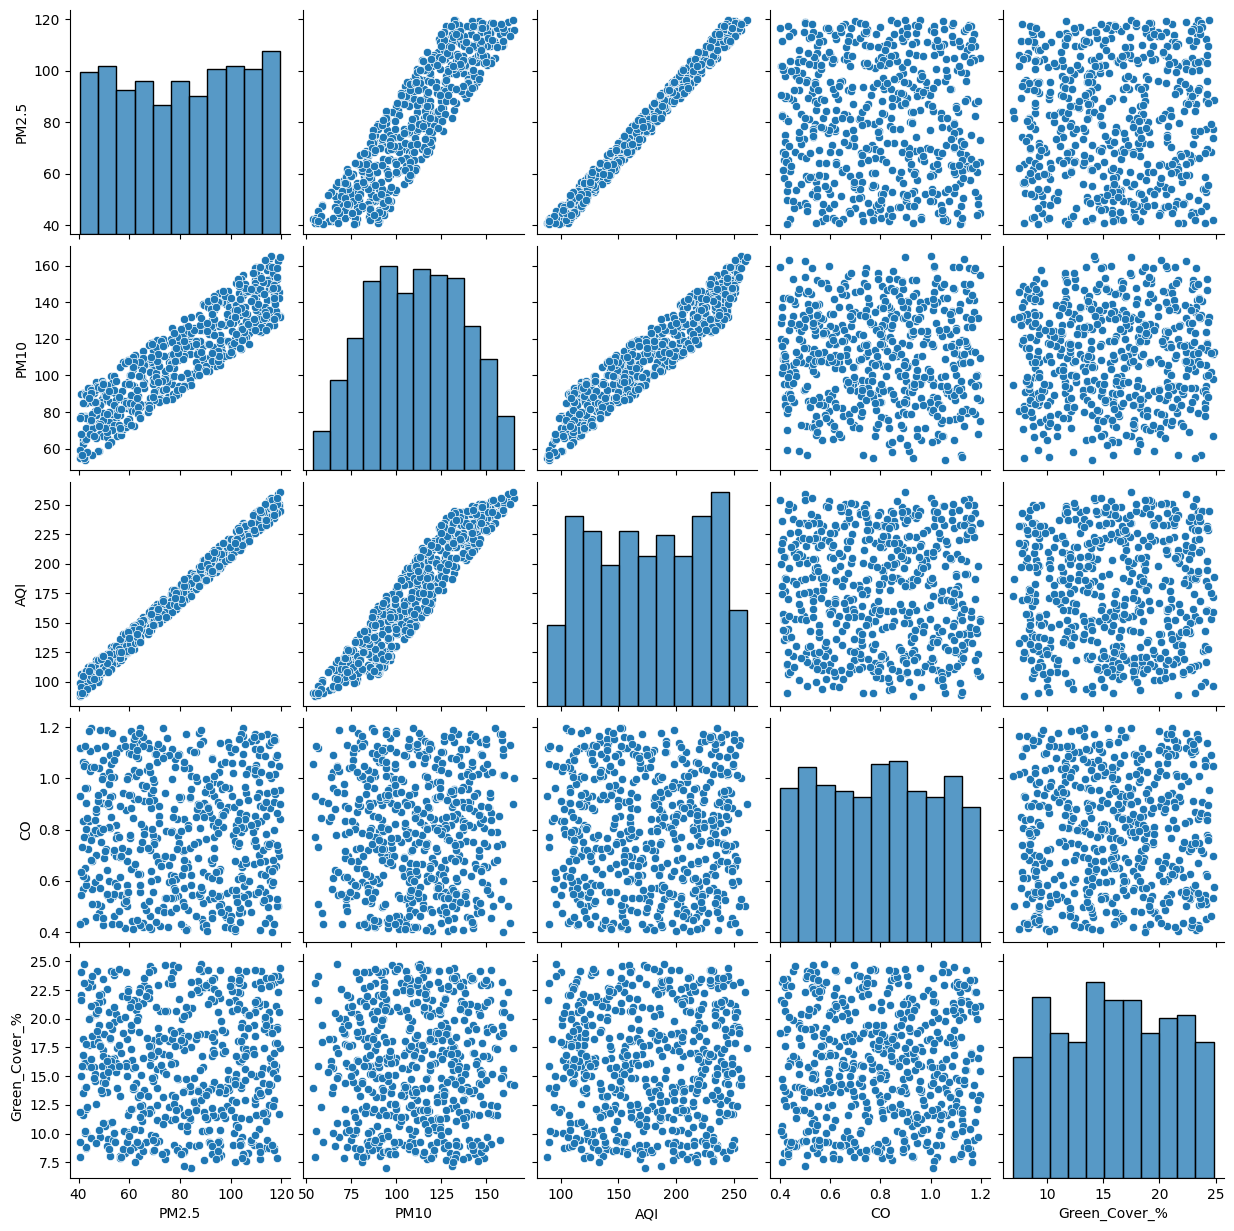

In [7]:
# Correlation matrix (simple)
df[['PM2.5','PM10','CO','AQI','Green_Cover_%']].corr()

# Or visualize
import seaborn as sns
sns.pairplot(df[['PM2.5','PM10','AQI','CO','Green_Cover_%']])


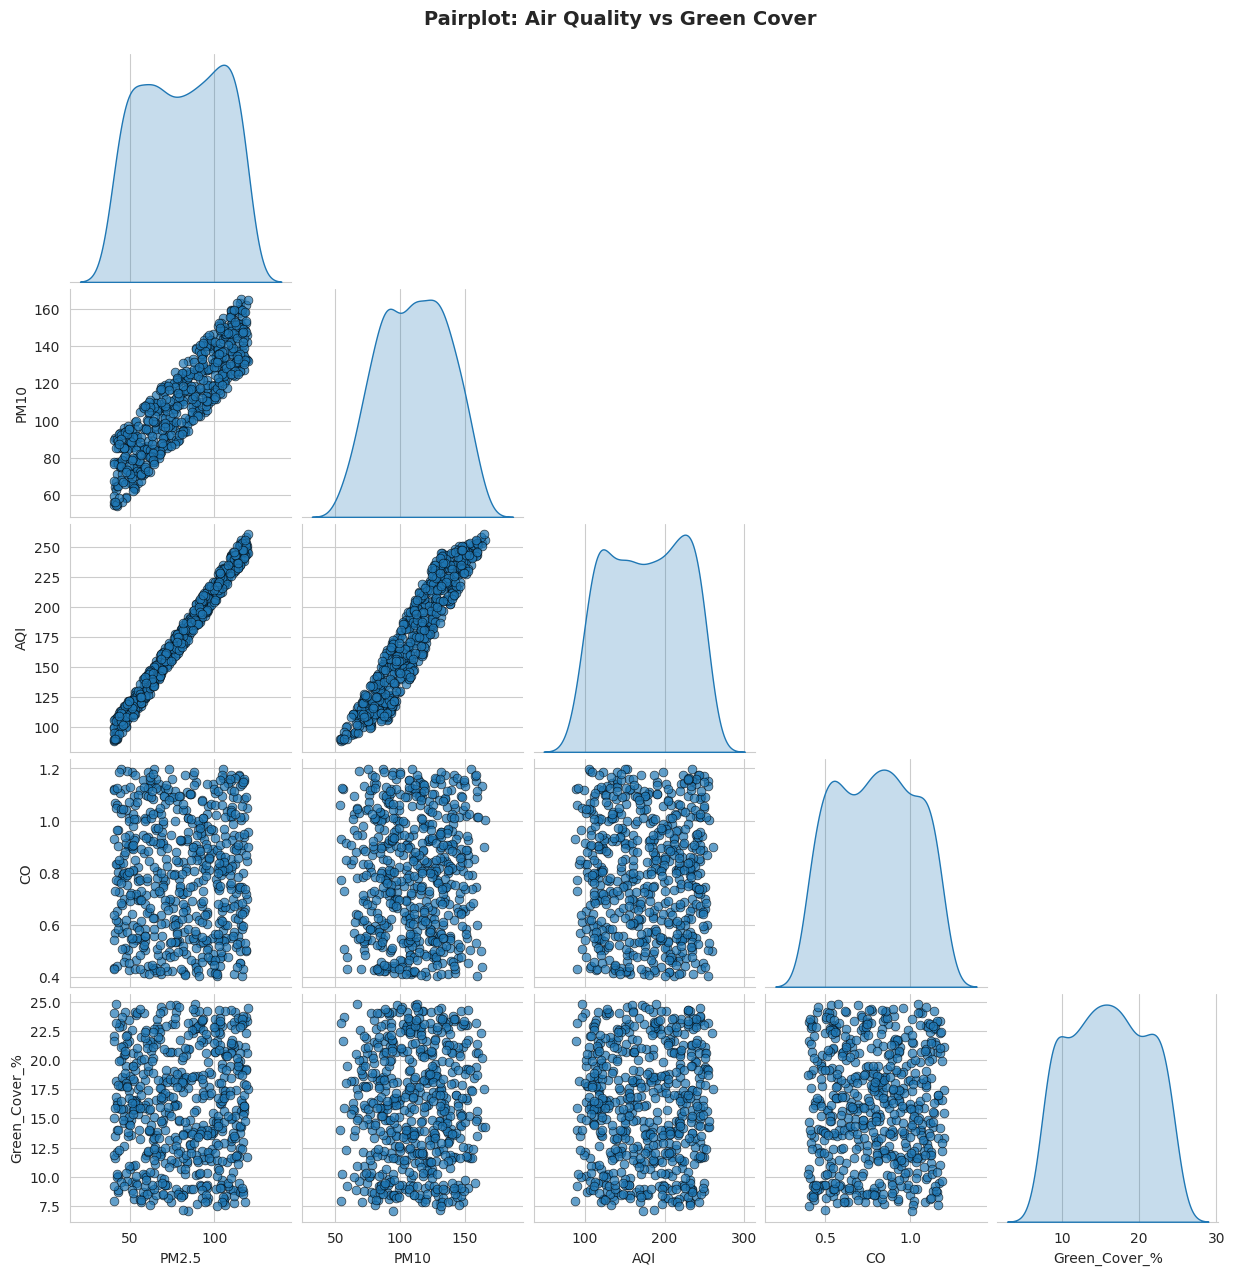

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use a clean Seaborn style
sns.set_style("whitegrid")

# Make the pairplot
sns.pairplot(
    df[['PM2.5','PM10','AQI','CO','Green_Cover_%']],
    diag_kind='kde',      # smooth curve on diagonal
    corner=True,           # show only half for clarity
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'k'}
)

# Add a simple title
plt.suptitle("Pairplot: Air Quality vs Green Cover", fontsize=14, weight='bold', y=1.02)

plt.show()


Converting Year, month, day to datetime

In [13]:
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['date'] = pd.to_datetime(dict(year=df.Year, month=df.Month, day=1))
df.head()

,City,Year,Month,PM2.5,PM10,CO,AQI,Green_Cover_%,date
0,Dhaka,2016,1,69.963210,117.991782,0.985595,163,18.177194,2016-01-01
1,Dhaka,2016,2,52.479562,64.802906,1.092941,111,18.218955,2016-02-01
2,Dhaka,2016,3,41.646760,90.443154,1.065954,107,11.609765,2016-03-01
3,Dhaka,2016,4,54.672361,76.842051,0.819805,120,15.343065,2016-04-01
4,Dhaka,2016,5,88.948232,104.527986,0.633716,185,14.228151,2016-05-01


Checking Null value after converting

In [14]:
num_cols = ['PM2.5','PM10','CO','AQI','Green_Cover_%']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
# check missing again
display(df[num_cols].isna().sum())

,0
PM2.5,0
PM10,0
CO,0
AQI,0
Green_Cover_%,0


Monthly average AQI per city

In [34]:
aqi_monthly = df.groupby(['date','City'])['AQI'].mean().unstack('City')
aqi_monthly.head()

City,Barisal,Chittagong,Dhaka,Khulna,Rajshahi,Sylhet
date,,,,,,
2016-01-01,140.0,199.0,163.0,242.0,196.0,110.0
2016-02-01,189.0,230.0,111.0,127.0,111.0,156.0
2016-03-01,197.0,170.0,107.0,176.0,189.0,209.0
2016-04-01,246.0,153.0,120.0,247.0,219.0,138.0
2016-05-01,111.0,207.0,185.0,161.0,101.0,153.0


Text(0, 0.5, 'AQI')

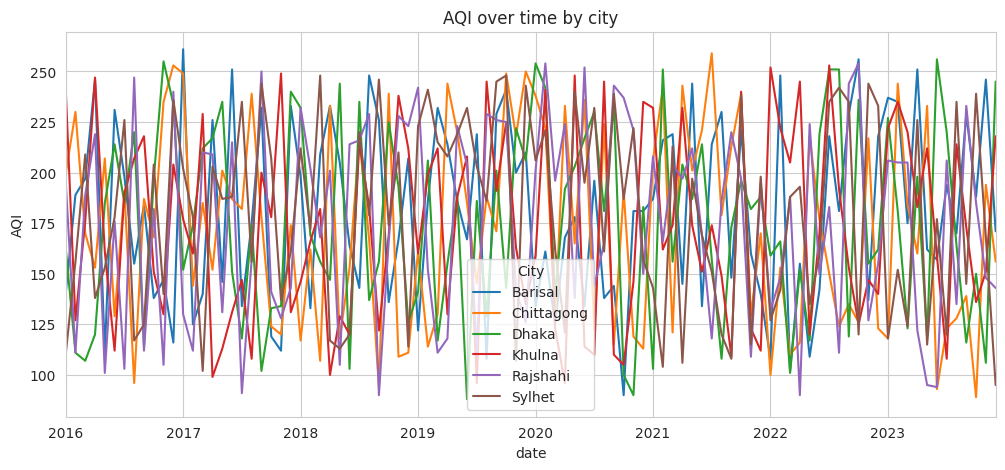

In [35]:
# monthly average AQI per city
aqi_monthly.plot(figsize=(12,5),
                 legend=True)
plt.title("AQI over time by city")
plt.ylabel("AQI")

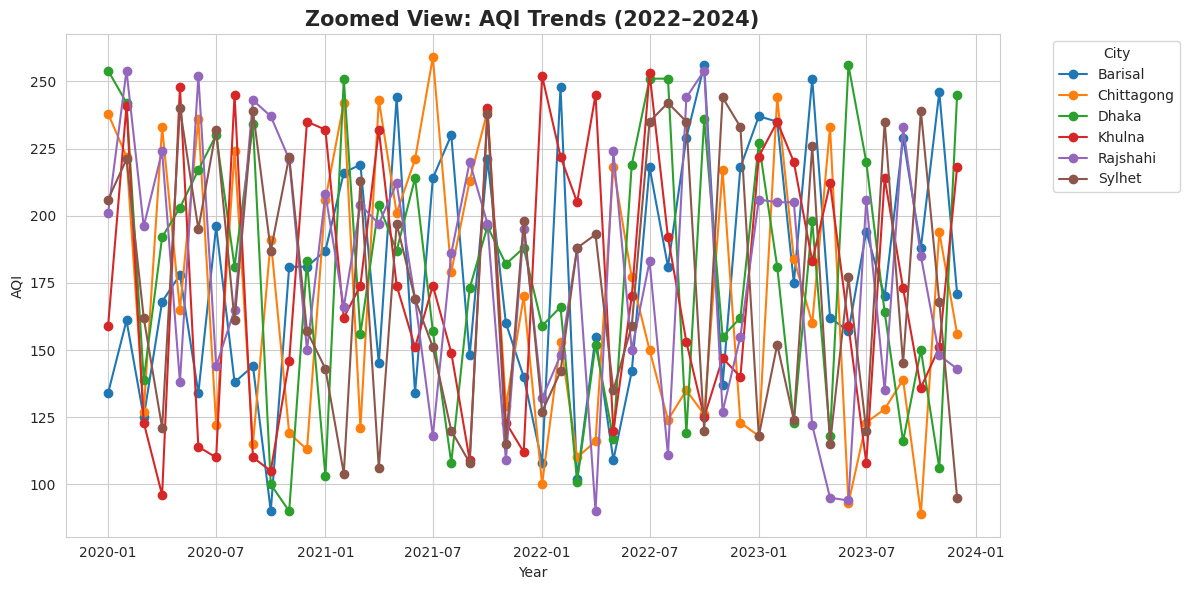

In [29]:
# Filter data between 2016 and 2024
zoom_df = aqi_monthly.loc['2020':'2024']

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

for city in zoom_df.columns:
    plt.plot(zoom_df.index, zoom_df[city], label=city, marker='o')

plt.title("Zoomed View: AQI Trends (2022–2024)", fontsize=15, weight='bold')
plt.xlabel("Year")
plt.ylabel("AQI")
plt.legend(title="City", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


Text(0, 0.5, 'AQI')

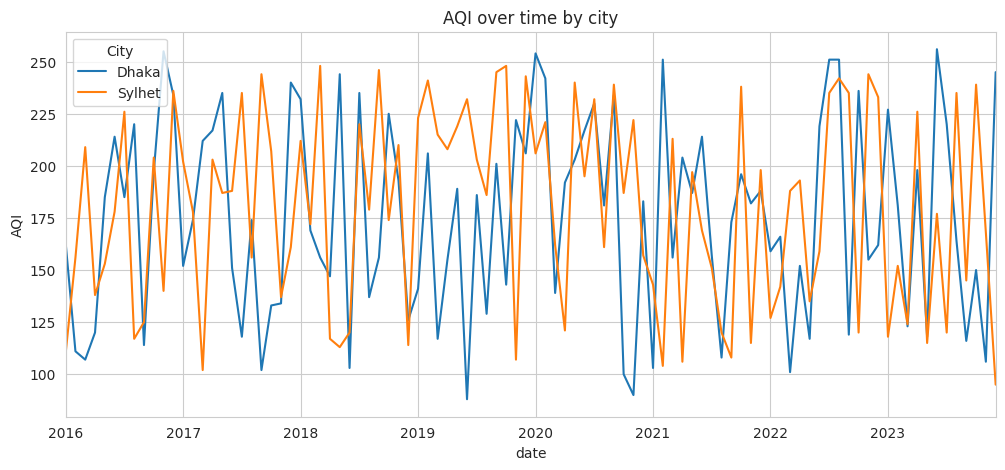

In [36]:
# Select only Dhaka and Sylhet
aqi_two = aqi_monthly[['Dhaka', 'Sylhet']]
aqi_two.plot(figsize=(12,5),
                 legend=True)
plt.title("AQI over time by city")
plt.ylabel("AQI")

Zoomed view of two cities from 2020 to 2024

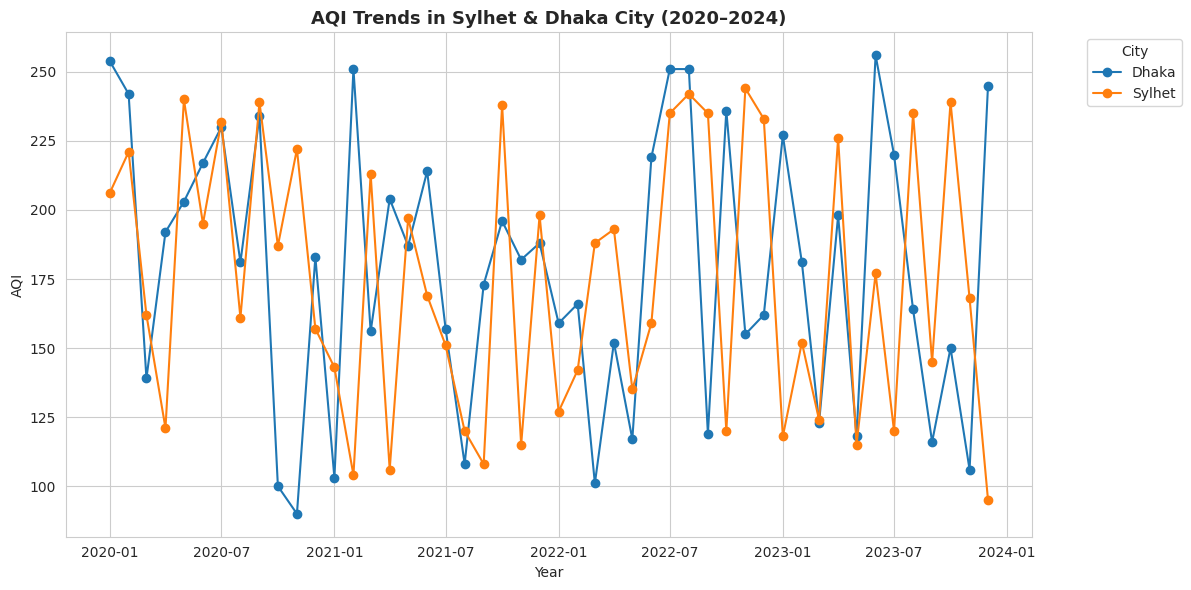

In [27]:
zoom_df = aqi_two.loc['2020':'2024']

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

for city in zoom_df.columns:
    plt.plot(zoom_df.index, zoom_df[city], label=city, marker='o')

plt.title("AQI Trends in Sylhet & Dhaka City (2020–2024)", fontsize=13, weight='bold')
plt.xlabel("Year")
plt.ylabel("AQI")
plt.legend(title="City", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()